### This code calculates the lattice Green's functions and the lattice level two-impurity interference in strontium ruthenate
### for different impurity orientations.
### Change theta_in_degree to change impurity orientation
### Here we double count due to particle and hole. We need to divide by two. But then we need to multiply by two for spin. At the end, this is OK.

In [1]:
using LinearAlgebra
using FFTW
using Plots

In [2]:
t_start = time();

In [3]:
a = 1;

### Now define the BZ and the k-space grid
N = 400
k_vals = range(-pi / a, stop=pi / a, length=N + 1)[1:end-1]
kx_grid = collect(k_vals)
ky_grid = collect(k_vals)

dk = 2 * pi / (N * a) # grid spacing in k-space


0.015707963267948967

In [4]:
t1 = 1.0;
t2 = 0.1;
t3 = 0.8;
t4 = 0.35;
t5 = 0.000;
t6 = 0.1;

mumu = 1.1;
deltadelta = -0.2;
mu_xz = mumu;
mu_yz = mumu;
mu_xy = mumu;

Delta_0 = t1/100;

T = Delta_0/2;

nn = 10;
omega_n_grid = range(1,nn,nn)*2 * pi * T - pi * T * ones(nn);

In [5]:
I2 = [1 0; 0 1];
I4 = [I2 zeros(2, 2); zeros(2, 2) I2];

In [6]:
function g_k(kx,ky)
    return -4*t6*sin(kx)*sin(ky)
end

function e_xz(kx,ky)
    return (-2*t1*cos(kx) - 2*t2*cos(ky) - mu_xz)
end

function e_yz(kx,ky)
    return (-2*t1*cos(ky) - 2*t2*cos(kx) - mu_yz)
end

e_yz (generic function with 1 method)

In [7]:
function H_plus(kx, ky)
    return (0.5*(e_xz(kx,ky) + e_yz(kx,ky)) +  sqrt(0.25*(e_xz(kx,ky) - e_yz(kx,ky))^2 + g_k(kx,ky)^2))
end

function H_minus(kx, ky)
    return (0.5*(e_xz(kx,ky) + e_yz(kx,ky)) -  sqrt(0.25*(e_xz(kx,ky) - e_yz(kx,ky))^2 + g_k(kx,ky)^2))
end

H_minus (generic function with 1 method)

In [8]:
function Delta_plus(kx, ky)
    return Delta_0*2*((cos(ky) - cos(kx)) + im*sin(kx)*sin(ky));
end

function Delta_minus(kx, ky)
    return Delta_0*2*((cos(ky-pi/a) - cos(kx-pi/a)) + im*sin(kx-pi/a)*sin(ky-pi/a));
end

Delta_minus (generic function with 1 method)

In [9]:
function H_normal(kx, ky)
    return [H_plus(kx, ky) 0; 0 H_minus(kx, ky)]
end

function Delta_matrix(kx, ky)
    return [Delta_plus(kx, ky) 0; 0 Delta_minus(kx, ky)]
end

Delta_matrix (generic function with 1 method)

In [10]:
function H_BdG(kx, ky)
    return [H_normal(kx, ky) Delta_matrix(kx, ky); Delta_matrix(kx, ky)' -transpose(H_normal(-kx, -ky))]
end

H_BdG (generic function with 1 method)

In [11]:
H_BdG(1,2)

4×4 Matrix{ComplexF64}:
 -0.322976+0.0im             0.0+0.0im        …       0.0+0.0im
       0.0+0.0im        -2.15017+0.0im           0.019129+0.0153029im
 -0.019129-0.0153029im       0.0-0.0im               -0.0+0.0im
       0.0-0.0im        0.019129-0.0153029im      2.15017+0.0im

In [12]:
## Now generate a grid of real space points
Lx = 401;
Ly = 401;

In [13]:
### Here we set the impurity positions
dist_from_center = 15;

theta_in_degree = 30;
theta_rotate = theta_in_degree/180*pi;

imp_x1 = Int(round(Lx/2 - dist_from_center*cos(theta_rotate)))
imp_y1 = Int(round(Ly/2 - dist_from_center*sin(theta_rotate)))
imp_x2 = Int(round(Lx/2 + dist_from_center*cos(theta_rotate)))
imp_y2 = Int(round(Ly/2 + dist_from_center*sin(theta_rotate)))

208

In [14]:
### Green's function calculation
function G0_k(kx, ky, omega_n)
    return inv(omega_n*I4 - H_BdG(kx, ky))
end


G0_k (generic function with 1 method)

In [15]:
G0_k(1.0,1.0,0.1)

4×4 Matrix{ComplexF64}:
 0.474937+0.0im             0.0-0.0im        …        0.0+0.0im
      0.0+0.0im        0.374255-0.0im                 0.0-0.0021441im
      0.0+0.0035298im       0.0+0.0im                 0.0-0.0im
      0.0+0.0im             0.0+0.0021441im     -0.404536-0.0im

In [16]:
### Real space Green's function calculation (FFT-accelerated)
nDim = 4;
function precompute_G0_r_fft(omega_n)
    Gk = Array{ComplexF64}(undef, N, N, nDim, nDim)

    for (ix, kxv) in enumerate(kx_grid), (iy, kyv) in enumerate(ky_grid)
        Gk[ix, iy, :, :] = G0_k(kxv, kyv, omega_n)
    end

    # ifft contributes 1/N^2; multiply by 1/a^2 so normalization is dk^2/(2pi)^2 = 1/(N^2 a^2)
    norm_factor = 1 / a^2
    Gr = similar(Gk)
    for a in 1:nDim, b in 1:nDim
        Gr[:, :, a, b] = norm_factor * ifft(Gk[:, :, a, b])
    end
    return Gr
end

function G0_r_from_fft(cache, x1, y1, x2, y2)
    dx = x1 - x2
    dy = y1 - y2
    ix = mod(dx, N) + 1
    iy = mod(dy, N) + 1

    # k-grid starts at -pi, so include phase exp(-i*pi*(dx+dy)) = (-1)^(dx+dy)
    phase = isodd(dx + dy) ? -1.0 : 1.0
    return phase .* cache[ix, iy, :, :]
end


G0_r_from_fft (generic function with 1 method)

In [17]:
G0_cache = precompute_G0_r_fft(0.0 + 0.0im);

In [18]:
size(G0_cache)

(400, 400, 4, 4)

In [19]:
G0_r_from_fft(G0_cache, 1, 2, 3, 4)

4×4 Matrix{ComplexF64}:
    0.0328045+2.21932e-18im  …           0.0+0.0im
          0.0+0.0im             -5.11591e-17+0.170623im
 -4.26326e-18+0.10625im                  0.0+0.0im
          0.0+0.0im                0.0667551+4.85327e-18im

In [20]:
V_imp_matrix = kron([1 0; 0 -1],I2); # potential for the impurity in Nambu space

In [21]:
eps = Delta_0/100;

In [22]:
omega_n_grid

10-element Vector{Float64}:
 0.015707963267948967
 0.0471238898038469
 0.07853981633974483
 0.10995574287564278
 0.1413716694115407
 0.17278759594743864
 0.20420352248333656
 0.2356194490192345
 0.2670353755551324
 0.2984513020910303

In [23]:
LDOS_plus = zeros(Float64, Lx, Ly)
LDOS_minus = zeros(Float64, Lx, Ly)

for iii = 1:nn

    println("Processing Matsubara frequency ", iii, " / ", nn)
    omega_n_value_1 = omega_n_grid[iii];
    omega_n_value_2 = omega_n_value_1 - im*eps;

G0_cache_first = precompute_G0_r_fft(im*omega_n_value_1)
G0_cache_second = precompute_G0_r_fft(im*omega_n_value_2)

G_12_first = G0_r_from_fft(G0_cache_first, imp_x1, imp_y1, imp_x2, imp_y2)
G_21_first = G0_r_from_fft(G0_cache_first, imp_x2, imp_y2, imp_x1, imp_y1)

G_12_second = G0_r_from_fft(G0_cache_second, imp_x1, imp_y1, imp_x2, imp_y2)
G_21_second = G0_r_from_fft(G0_cache_second, imp_x2, imp_y2, imp_x1, imp_y1)

for x in 1:Lx
    for y in 1:Ly
        G_x1_first = G0_r_from_fft(G0_cache_first, x, y, imp_x1, imp_y1)
        G_2x_first = G0_r_from_fft(G0_cache_first, imp_x2, imp_y2, x, y)

        G_1x_first = G0_r_from_fft(G0_cache_first, imp_x1, imp_y1, x, y)
        G_x2_first = G0_r_from_fft(G0_cache_first, x, y, imp_x2, imp_y2)

        G_x1_second = G0_r_from_fft(G0_cache_second, x, y, imp_x1, imp_y1)
        G_2x_second = G0_r_from_fft(G0_cache_second, imp_x2, imp_y2, x, y)

        G_1x_second = G0_r_from_fft(G0_cache_second, imp_x1, imp_y1, x, y)
        G_x2_second = G0_r_from_fft(G0_cache_second, x, y, imp_x2, imp_y2)

        value_matrix = im*zeros(4,4);

        value_matrix -= G_x1_first * V_imp_matrix * G_12_first * V_imp_matrix * G_2x_first
        value_matrix -= G_x2_first * V_imp_matrix * G_21_first * V_imp_matrix * G_1x_first
        value_matrix += G_x1_second * V_imp_matrix * G_12_second * V_imp_matrix * G_2x_second
        value_matrix += G_x2_second * V_imp_matrix * G_21_second * V_imp_matrix * G_1x_second

        val_matrix = value_matrix/eps;

        LDOS_plus[x, y] += T*real(val_matrix[1, 1] + val_matrix[3, 3]);
        LDOS_minus[x, y] += T*real(val_matrix[2, 2] + val_matrix[4, 4]);
    end
end

end

Processing Matsubara frequency 1 / 10
Processing Matsubara frequency 2 / 10
Processing Matsubara frequency 3 / 10
Processing Matsubara frequency 4 / 10
Processing Matsubara frequency 5 / 10
Processing Matsubara frequency 6 / 10
Processing Matsubara frequency 7 / 10
Processing Matsubara frequency 8 / 10
Processing Matsubara frequency 9 / 10
Processing Matsubara frequency 10 / 10


In [24]:
## Set the values at the two impurities to zero for both orbitals
LDOS_plus[imp_x1, imp_y1] = 0.0;
LDOS_plus[imp_x2, imp_y2] = 0.0;
LDOS_minus[imp_x1, imp_y1] = 0.0;
LDOS_minus[imp_x2, imp_y2] = 0.0;

In [25]:
using DelimitedFiles
writedlm("LDOS_d+id_plus_theta_$(theta_in_degree)_julia_code_strontium_ruthenate_BdG.csv", LDOS_plus, ',')
writedlm("LDOS_d+id_minus_theta_$(theta_in_degree)_julia_code_strontium_ruthenate_BdG.csv", LDOS_minus, ',')

In [26]:
custom_cmap = cgrad([:blue, :white, :orange], [0.4, 0.6])

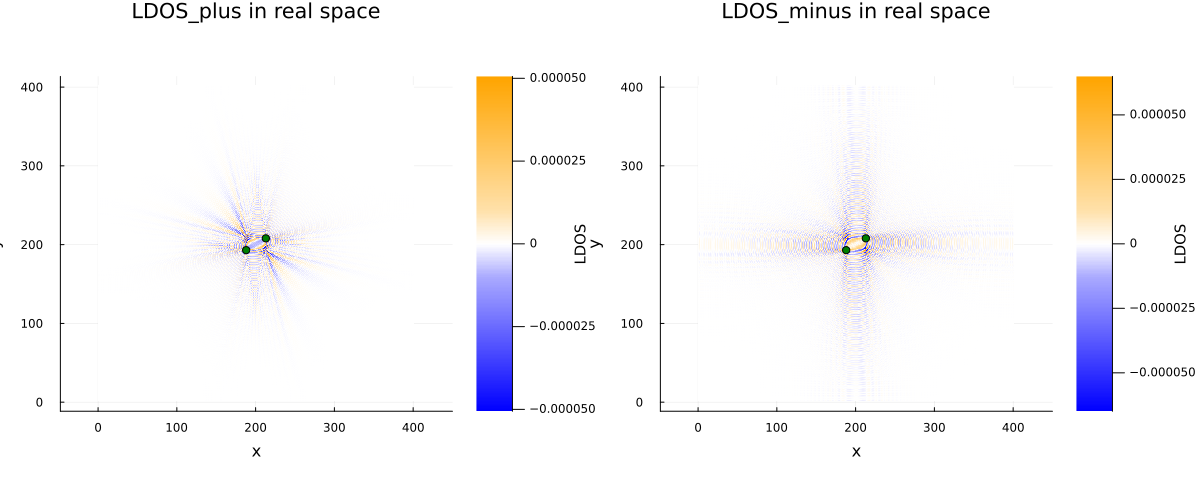

In [27]:
### Now we plot LDOS_plus and LDOS_minus in real space (zoomed around center)
clip_xz = maximum(abs.(LDOS_plus));
clip_yz = maximum(abs.(LDOS_minus));

p_xz = heatmap(LDOS_plus', xlabel="x", ylabel="y", title="LDOS_plus in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip_xz, clip_xz))
scatter!(p_xz, [imp_x1, imp_x2], [imp_y1, imp_y2], markersize=4, markerstrokewidth=1, color=:green, label="Impurities", legend=false)

p_yz = heatmap(LDOS_minus', xlabel="x", ylabel="y", title="LDOS_minus in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip_yz, clip_yz))
scatter!(p_yz, [imp_x1, imp_x2], [imp_y1, imp_y2], markersize=4, markerstrokewidth=1, color=:green, label="Impurities", legend=false)

plot(p_xz, p_yz, layout=(1,2), size=(1200, 500))

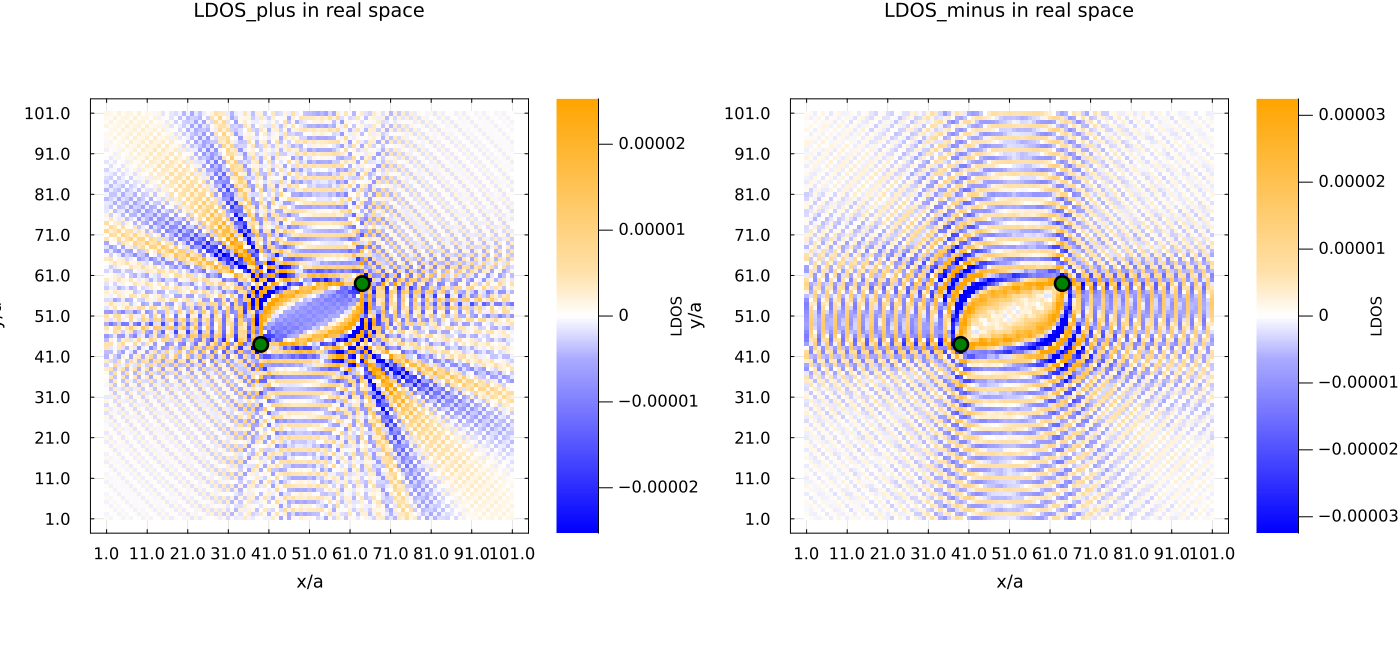

In [28]:
### Publication quality plots: LDOS_plus and LDOS_minus in real space (zoomed around center) with x/a and y/a axes
xrange = (Int(round(Lx / 2)) - 50):(Int(round(Lx / 2)) + 50)
yrange = (Int(round(Ly / 2)) - 50):(Int(round(Ly / 2)) + 50)

# Convert to normalized coordinates (x/a, y/a)
x_coords = (collect(xrange) .- 1) ./ a
y_coords = (collect(yrange) .- 1) ./ a

# Relabel x-axis from 1 to (max - min)
x_shift = minimum(x_coords)
x_labels = x_coords .- x_shift .+ 1

idx = 1:10:length(x_coords)  # keep every 10th tick
xt = (x_coords[idx], round.(x_labels[idx]; digits=1))

clip_xz = maximum(abs.(LDOS_plus[xrange, yrange]))/2
clip_yz = maximum(abs.(LDOS_minus[xrange, yrange]))/2

p_xz_pub = heatmap(x_coords, y_coords, LDOS_plus[xrange, yrange]', 
    xlabel="x/a", ylabel="y/a", 
    title="LDOS_plus in real space",
    colorbar_title="LDOS", 
    c=custom_cmap, 
    aspect_ratio=1, 
    clim=(-clip_xz, clip_xz),
    framestyle=:box,
    legend=false,
    size=(800, 700),
    margin=2Plots.mm,
    tickfontsize=11,
    guidefontsize=12,
    titlefontsize=13,
    colorbar=:right,
    xticks=xt,
    yticks=xt
)

# Add impurity positions (convert from 1-based index to physical coordinates)
scatter!(p_xz_pub, [(imp_x1 - 1) ./ a, (imp_x2 - 1) ./ a], 
         [(imp_y1 - 1) ./ a, (imp_y2 - 1) ./ a],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

p_yz_pub = heatmap(x_coords, y_coords, LDOS_minus[xrange, yrange]', 
    xlabel="x/a", ylabel="y/a", 
    title="LDOS_minus in real space",
    colorbar_title="LDOS", 
    c=custom_cmap, 
    aspect_ratio=1, 
    clim=(-clip_yz, clip_yz),
    framestyle=:box,
    legend=false,
    size=(800, 700),
    margin=2Plots.mm,
    tickfontsize=11,
    guidefontsize=12,
    titlefontsize=13,
    colorbar=:right,
    xticks=xt,
    yticks=xt
)

scatter!(p_yz_pub, [(imp_x1 - 1) ./ a, (imp_x2 - 1) ./ a], 
         [(imp_y1 - 1) ./ a, (imp_y2 - 1) ./ a],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

plot(p_xz_pub, p_yz_pub, layout=(1,2), size=(1400, 650))

In [29]:
LDOS_interesting_xz = LDOS_plus[xrange, yrange];
LDOS_interesting_yz = LDOS_minus[xrange, yrange];

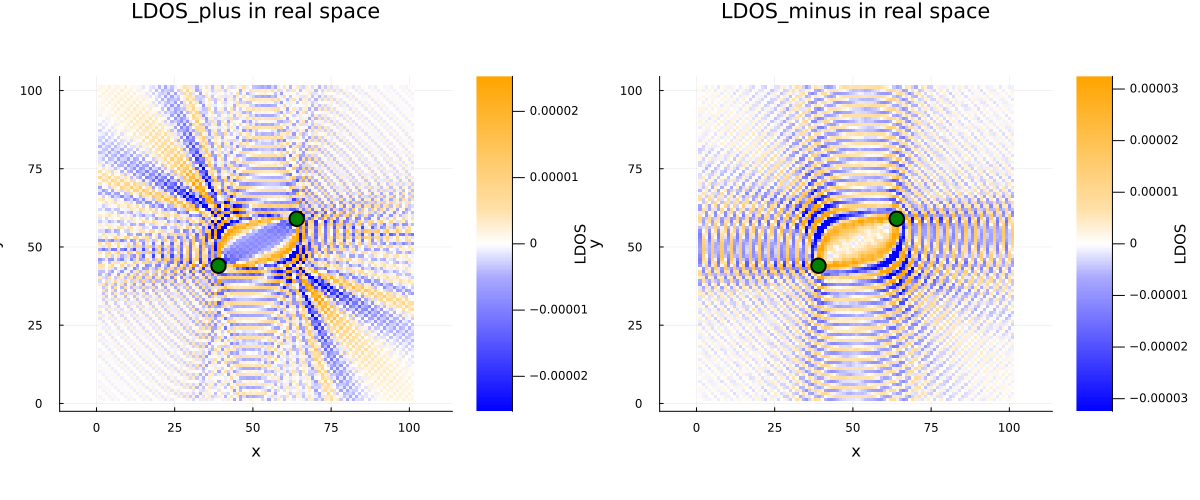

In [30]:
### Now we plot LDOS_plus and LDOS_minus in real space (zoomed around center)
xrange = (Int(round(Lx / 2)) - 50):(Int(round(Lx / 2)) + 50)
yrange = (Int(round(Ly / 2)) - 50):(Int(round(Ly / 2)) + 50)

clip_xz = maximum(abs.(LDOS_plus[xrange, yrange]))/2;
clip_yz = maximum(abs.(LDOS_minus[xrange, yrange]))/2;

p_xz_zoom = heatmap(LDOS_plus[xrange, yrange]', xlabel="x", ylabel="y", title="LDOS_plus in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip_xz, clip_xz))
scatter!(p_xz_zoom, [imp_x1 - xrange[1] + 1, imp_x2 - xrange[1] + 1], [imp_y1 - yrange[1] + 1, imp_y2 - yrange[1] + 1],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

p_yz_zoom = heatmap(LDOS_minus[xrange, yrange]', xlabel="x", ylabel="y", title="LDOS_minus in real space", colorbar_title="LDOS", c=custom_cmap, aspect_ratio=1, clim=(-clip_yz, clip_yz))
scatter!(p_yz_zoom, [imp_x1 - xrange[1] + 1, imp_x2 - xrange[1] + 1], [imp_y1 - yrange[1] + 1, imp_y2 - yrange[1] + 1],
    markersize=8, markerstrokewidth=2, color=:green,
    label="Impurities", legend=false
)

plot(p_xz_zoom, p_yz_zoom, layout=(1,2), size=(1200, 500))

In [ ]:
t_stop = time();
println("Time taken: ", t_stop - t_start, " seconds")

Time taken: 287.7050940990448 seconds
